# Car Price Prediction with Machine Learning

**Goal:** Predict the selling price of a used car from features such as brand, age, mileage, fuel type, and transmission.




In [1]:
#Imports & Setup libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


In [2]:
# dataset loading and reading
df = pd.read_csv("car_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (925, 9)


,name,year,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner
0,Tata Safari,2015,1.98,9.44,100817.0,CNG,Individual,Manual,First Owner
1,Mahindra Thar,2010,1.47,10.97,181631.0,Diesel,Dealer,Manual,First Owner
2,BMW 3 Series,2017,14.99,49.90,106140.0,Petrol,Dealer,Manual,First Owner
3,BMW X1,2004,2.53,47.14,272229.0,Petrol,Individual,Manual,Third Owner
4,Renault Triber,2019,2.77,6.12,93791.0,Diesel,Trustmark Dealer,Manual,First Owner


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 925 entries, 0 to 924
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           925 non-null    str    
 1   year           925 non-null    int64  
 2   selling_price  925 non-null    float64
 3   present_price  912 non-null    float64
 4   kms_driven     907 non-null    float64
 5   fuel_type      916 non-null    str    
 6   seller_type    925 non-null    str    
 7   transmission   925 non-null    str    
 8   owner          912 non-null    str    
dtypes: float64(3), int64(1), str(5)
memory usage: 105.4 KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,925,54,Volkswagen Polo,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,925.0,NaN,NaN,NaN,2011.875676,4.78371,2004.0,2008.0,2012.0,2016.0,2020.0
selling_price,925.0,NaN,NaN,NaN,3.157697,3.800641,0.37,1.02,1.86,3.68,31.93
present_price,912.0,NaN,NaN,NaN,16.283169,14.612133,6.0,8.1675,9.83,14.285,59.97
kms_driven,907.0,NaN,NaN,NaN,182362.125689,78832.221893,33811.0,118753.0,176956.0,238493.5,395959.0
fuel_type,916,14,Petrol,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,925,11,Dealer,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,925,8,Manual,699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,912,4,First Owner,579,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data cleaning ##

In [5]:
# Missing values 
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


Missing values per column:
name              0
year              0
selling_price     0
present_price    13
kms_driven       18
fuel_type         9
seller_type       0
transmission      0
owner            13
dtype: int64

Total missing cells: 53


In [6]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")


Duplicate rows found: 25
Shape after dropping duplicates: (900, 9)


In [7]:
# Inconsistent categorical values
categorical_cols = ["fuel_type", "seller_type", "transmission", "owner"]

print("Unique values BEFORE cleaning:")
for c in categorical_cols:
    print(f"  {c}: {sorted(df[c].dropna().unique().tolist())}")


Unique values BEFORE cleaning:
  fuel_type: [' CNG ', ' Diesel ', ' LPG ', ' Petrol ', 'CNG', 'DIESEL', 'Diesel', 'LPG', 'PETROL', 'Petrol', 'cng', 'diesel', 'lpg', 'petrol']
  seller_type: [' Dealer ', ' Individual ', 'DEALER', 'Dealer', 'INDIVIDUAL', 'Individual', 'TRUSTMARK DEALER', 'Trustmark Dealer', 'dealer', 'individual', 'trustmark dealer']
  transmission: [' Automatic ', ' Manual ', 'AUTOMATIC', 'Automatic', 'MANUAL', 'Manual', 'automatic', 'manual']
  owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Third Owner']


In [8]:
# Standardize: strip whitespace, title-case
for c in categorical_cols:
    df[c] = df[c].astype(str).str.strip().str.title()
    df.loc[df[c] == "Nan", c] = np.nan  # str() turned real NaNs into the string "Nan"

print("Unique values AFTER cleaning:")
for c in categorical_cols:
    print(f"  {c}: {sorted(df[c].dropna().unique().tolist())}")


Unique values AFTER cleaning:
  fuel_type: ['Cng', 'Diesel', 'Lpg', 'Petrol']
  seller_type: ['Dealer', 'Individual', 'Trustmark Dealer']
  transmission: ['Automatic', 'Manual']
  owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Third Owner']


In [9]:
# Handle missing values
# Numeric columns: impute with median
for col in ["kms_driven", "present_price"]:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Categorical columns: impute with mode
for col in ["fuel_type", "owner"]:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

print("Missing values remaining:")
print(df.isnull().sum().sum())


Missing values remaining:
0


## Feature Engineering




In [10]:
CURRENT_YEAR = 2024

df["car_age"] = CURRENT_YEAR - df["year"]
df["brand"] = df["name"].str.split().str[0]

print("Number of unique brands:", df["brand"].nunique())
df[["name", "brand", "year", "car_age"]].head()


Number of unique brands: 12


,name,brand,year,car_age
0,Tata Safari,Tata,2015,9
1,Mahindra Thar,Mahindra,2010,14
2,BMW 3 Series,BMW,2017,7
3,BMW X1,BMW,2004,20
4,Renault Triber,Renault,2019,5


In [11]:
# Consolidate rare brands (fewer than 10 listings) into "Other" to avoid a sparse encoding
brand_counts = df["brand"].value_counts()
rare_brands = brand_counts[brand_counts < 10].index
df["brand"] = df["brand"].where(~df["brand"].isin(rare_brands), "Other")
df["brand"].value_counts()


brand
Volkswagen    85
Skoda         80
Hyundai       79
Maruti        78
Tata          77
Toyota        77
Mahindra      74
Honda         74
Audi          73
Renault       72
BMW           71
Ford          60
Name: count, dtype: int64

In [12]:
# Drop columns we no longer need for modeling
df_model = df.drop(columns=["name", "year"])
df_model.head()


,selling_price,present_price,kms_driven,fuel_type,seller_type,transmission,owner,car_age,brand
0,1.98,9.44,100817.0,Cng,Individual,Manual,First Owner,9,Tata
1,1.47,10.97,181631.0,Diesel,Dealer,Manual,First Owner,14,Mahindra
2,14.99,49.90,106140.0,Petrol,Dealer,Manual,First Owner,7,BMW
3,2.53,47.14,272229.0,Petrol,Individual,Manual,Third Owner,20,BMW
4,2.77,6.12,93791.0,Diesel,Trustmark Dealer,Manual,First Owner,5,Renault


## Exploratory Data Analysis (EDA)

### Distribution of Selling Prices

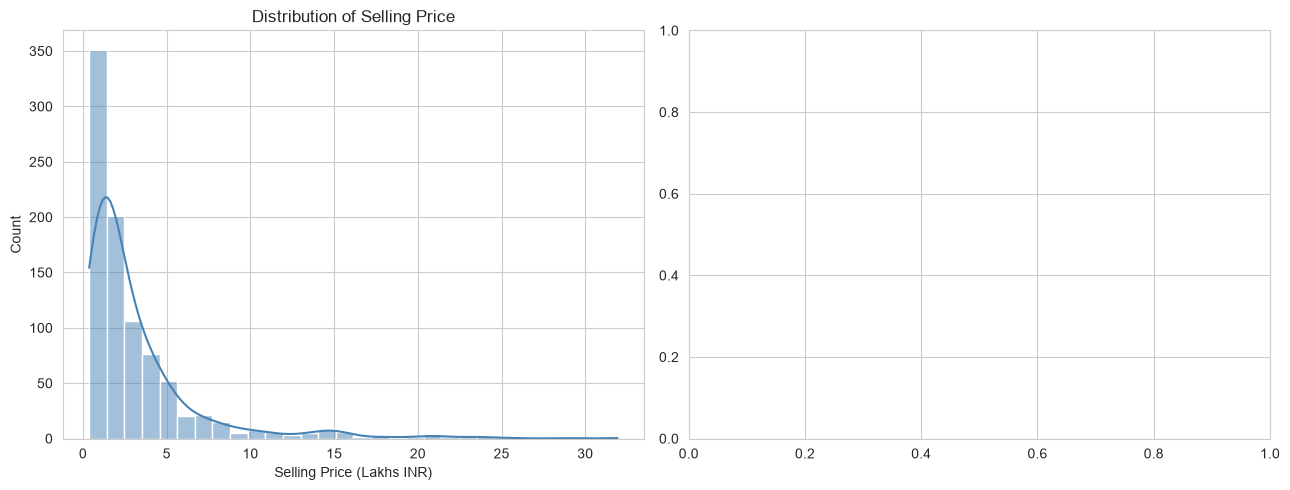

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df_model["selling_price"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Selling Price")
axes[0].set_xlabel("Selling Price (Lakhs INR)")


plt.tight_layout()
plt.show()


### Price vs Fuel Type

C:\Users\Admin\AppData\Local\Temp\ipykernel_18928\907952762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_model, x="fuel_type", y="selling_price", order=order, palette="viridis")


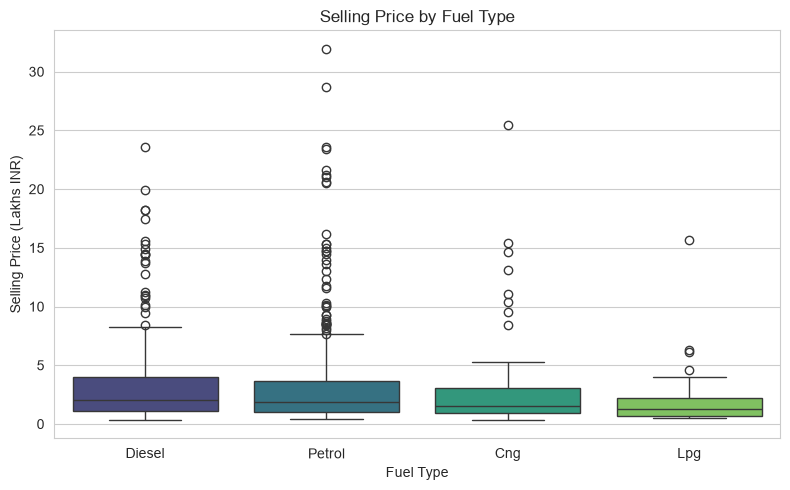

In [ ]:
plt.figure(figsize=(8, 5))
order = df_model.groupby("fuel_type")["selling_price"].median().sort_values(ascending=False).index
sns.boxplot(data=df_model, x="fuel_type", y="selling_price", order=order, palette="viridis")
plt.title("Selling Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price (Lakhs INR)")
plt.tight_layout()
plt.show()


### Price vs Car Age

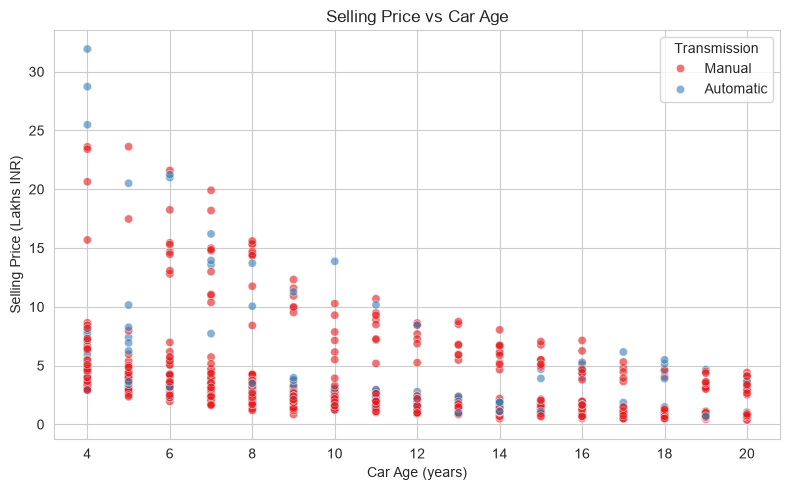

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_model, x="car_age", y="selling_price", hue="transmission",
                 alpha=0.6, palette="Set1")
plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age (years)")
plt.ylabel("Selling Price (Lakhs INR)")
plt.legend(title="Transmission")
plt.tight_layout()
plt.show()


##  Encode Categorical Variables




In [ ]:
categorical_cols = ["fuel_type", "seller_type", "transmission", "owner", "brand"]

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (900, 24)


,selling_price,present_price,kms_driven,car_age,fuel_type_Diesel,fuel_type_Lpg,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Third Owner,brand_BMW,brand_Ford,brand_Honda,brand_Hyundai,brand_Mahindra,brand_Maruti,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen
0,1.98,9.44,100817.0,9,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,1.47,10.97,181631.0,14,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,14.99,49.90,106140.0,7,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,2.53,47.14,272229.0,20,False,False,True,True,False,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False
4,2.77,6.12,93791.0,5,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False


## Feature Correlation Heatmap

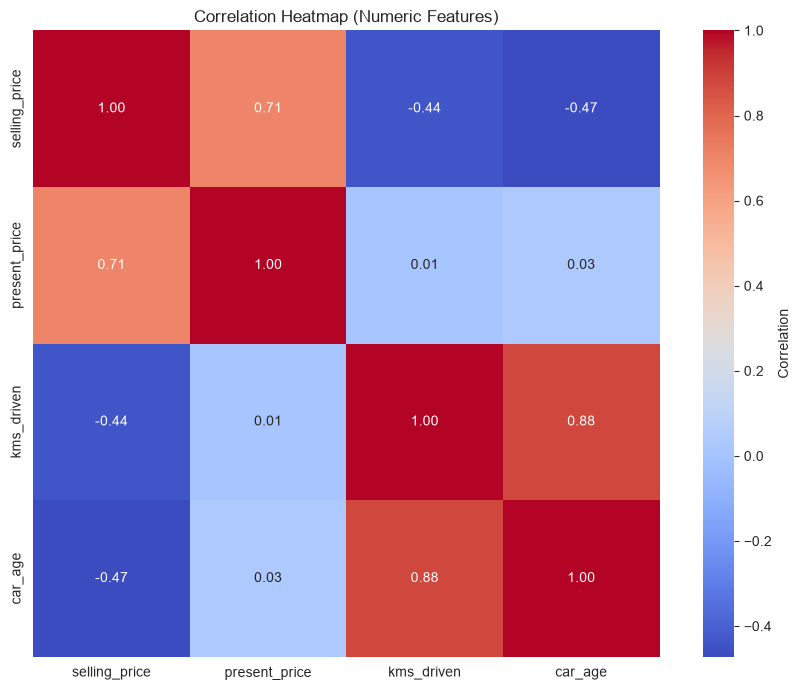

In [ ]:
plt.figure(figsize=(9, 7))
numeric_cols = ["selling_price", "present_price", "kms_driven", "car_age"]
corr = df_model[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


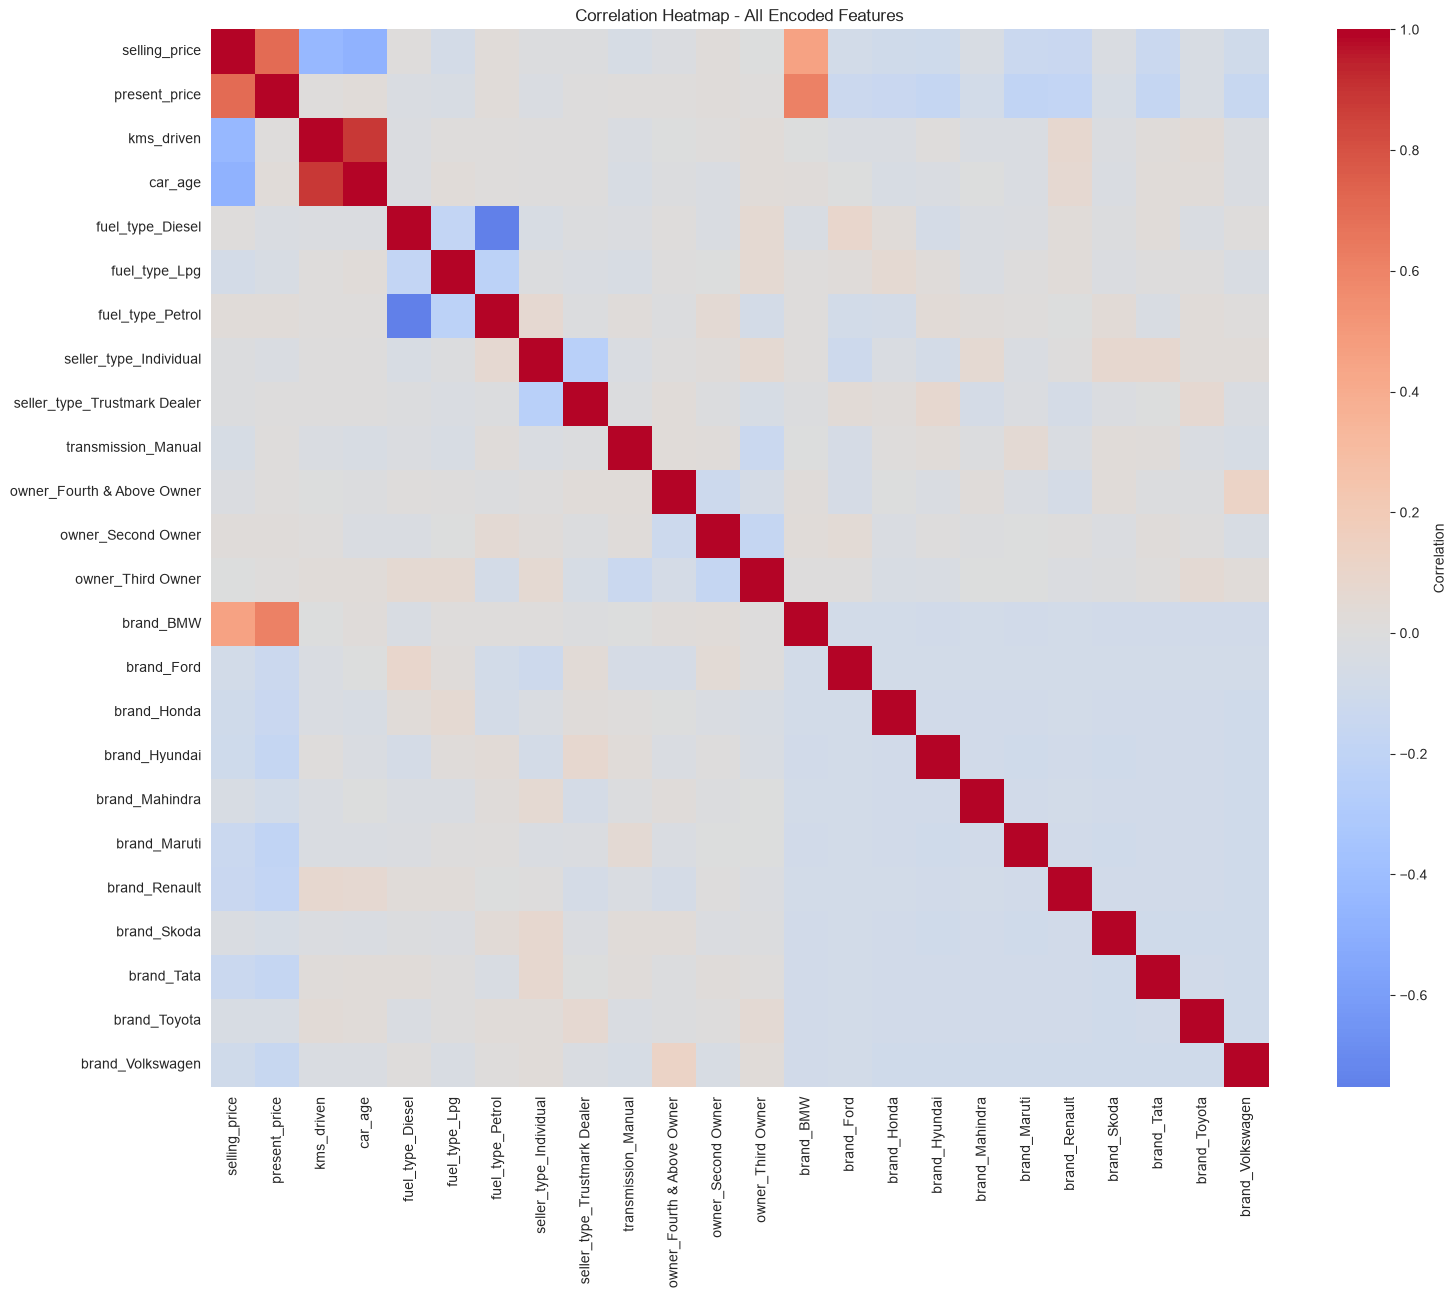

In [ ]:
# Full correlation heatmap including the one-hot encoded features
plt.figure(figsize=(16, 13))
full_corr = df_encoded.corr(numeric_only=True)
sns.heatmap(full_corr, cmap="coolwarm", center=0, square=True, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap - All Encoded Features")
plt.tight_layout()
plt.show()


## Train / Test Split

In [ ]:
X = df_encoded.drop(columns=["selling_price"])
y = df_encoded["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (720, 23)
Test shape: (180, 23)


## Model Training

We train three regression models and compare them:
1. **Linear Regression** — simple, interpretable baseline
2. **Random Forest Regressor** — bagged ensemble of decision trees, handles non-linearity well
3. **Gradient Boosting Regressor** — boosted ensemble, often the strongest performer on tabular data


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                     max_depth=3, random_state=RANDOM_STATE),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Trained: {name}")


Trained: Linear Regression
Trained: Random Forest
Trained: Gradient Boosting


##  Model Evaluation — MAE, RMSE, R²

In [ ]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Gradient Boosting,0.255113,0.456593,0.984939
1,Random Forest,0.325416,0.597023,0.974251
2,Linear Regression,1.132154,1.845823,0.753869


C:\Users\Admin\AppData\Local\Temp\ipykernel_18928\3531683077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, ax=ax, palette="mako")
C:\Users\Admin\AppData\Local\Temp\ipykernel_18928\3531683077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, ax=ax, palette="mako")
C:\Users\Admin\AppData\Local\Temp\ipykernel_18928\3531683077.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y=metric, ax=ax, palette="mako")


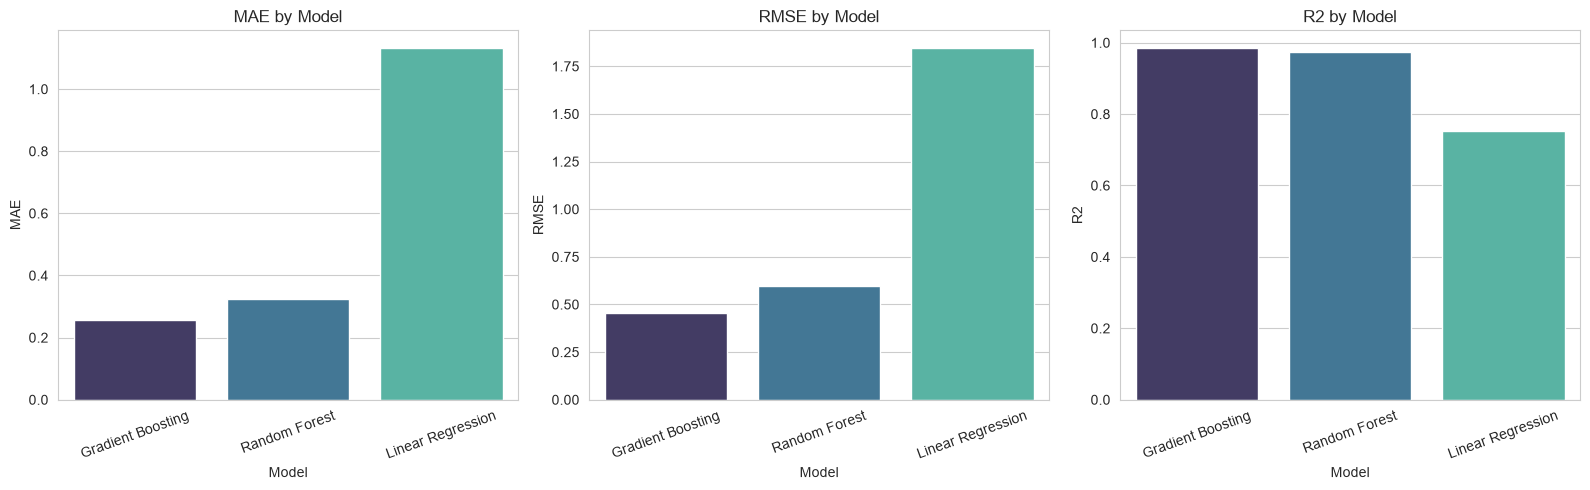

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    sns.barplot(data=results_df, x="Model", y=metric, ax=ax, palette="mako")
    ax.set_title(f"{metric} by Model")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [ ]:
best_model_name = results_df.loc[0, "Model"]
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(results_df.loc[0])


Best performing model: Gradient Boosting
Model    Gradient Boosting
MAE               0.255113
RMSE              0.456593
R2                0.984939
Name: 0, dtype: object


### Predicted vs Actual (Best Model)

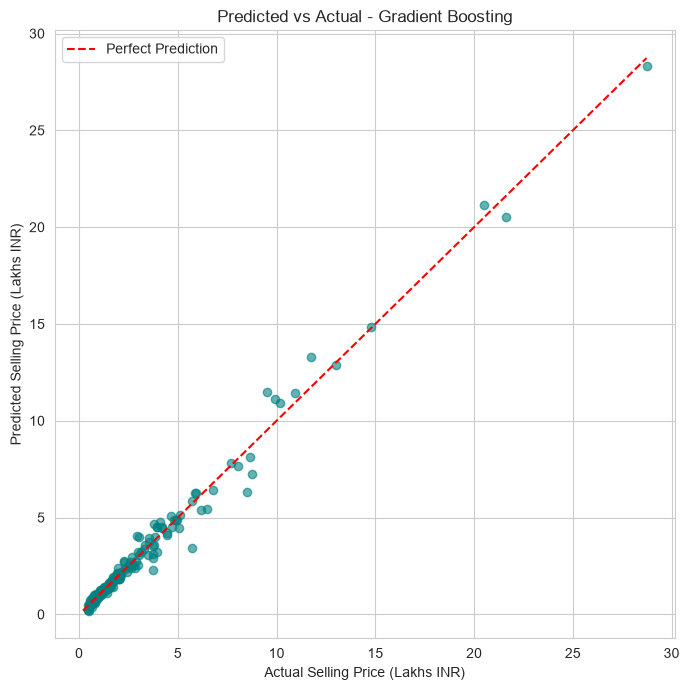

In [ ]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_best, alpha=0.6, color="teal")
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Selling Price (Lakhs INR)")
plt.ylabel("Predicted Selling Price (Lakhs INR)")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Importance (Best Model)

C:\Users\Admin\AppData\Local\Temp\ipykernel_18928\2074005549.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_importances.values, y=top_importances.index, palette="crest")


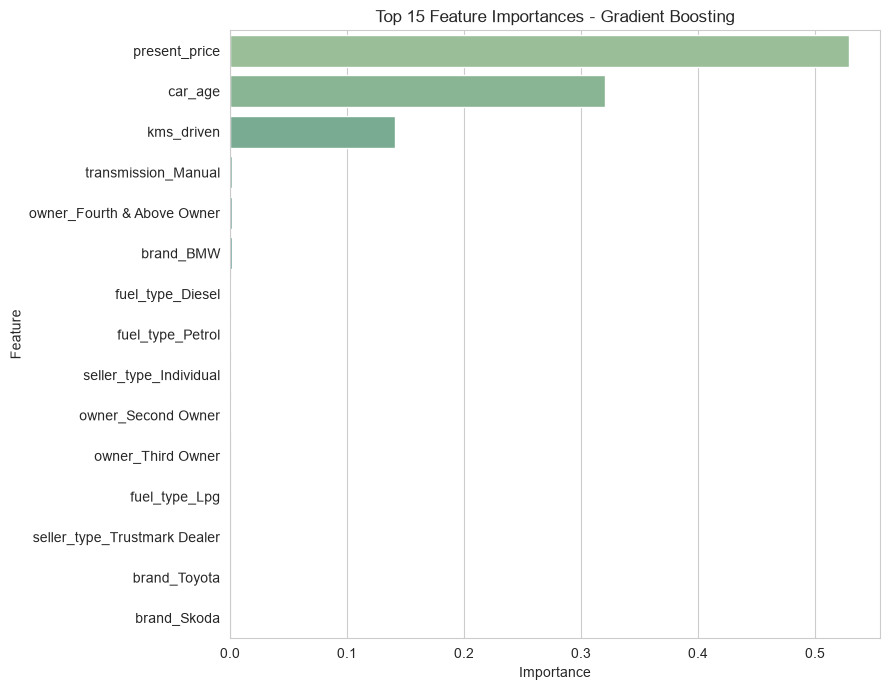

In [ ]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_), index=X.columns)
else:
    importances = pd.Series(dtype=float)

top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
sns.barplot(x=top_importances.values, y=top_importances.index, palette="crest")
plt.title(f"Top 15 Feature Importances - {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## Summary & Conclusions
The dataset was cleaned by removing duplicates, standardizing categorical values, and imputing missing data. The engineered **car age** and **present price** variables show strong relationships with **selling price**, indicating that older cars and those with lower original showroom prices generally resell for less. **Random Forest and Gradient Boosting** models outperform Linear Regression, reflecting the non-linear relationships between resale price and factors such as age, mileage, and ownership. Feature importance analysis further shows that **car age, present price, and kilometers driven** are the strongest predictors of resale price, while fuel type and transmission have a secondary influence.

